In [225]:
import pandas as pd
from pathlib import Path
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier, export_text

plt.style.use("seaborn-v0_8-darkgrid")

In [226]:
# Résumé des règles de l'arbre de décision

FEATURE_NAMES = ["T_out", "T_ctrl"]

def _find_thresholds_in_subtree(tree, node_id, feat_name, feature_names):
    """Retourne tous les thresholds de feat_name dans le sous-arbre node_id."""
    feat_idx = feature_names.index(feat_name)
    thresholds = []
    stack = [node_id]
    while stack:
        n = stack.pop()
        f = tree.feature[n]
        if f == feat_idx:
            thresholds.append(tree.threshold[n])
        if tree.children_left[n] != -1:  # pas une feuille
            stack.append(tree.children_left[n])
            stack.append(tree.children_right[n])
    return sorted(thresholds)

def resume_arbre_controle(tree_clf, df_features, label_col="OnOff_gmm"):
    """
    Résume les règles de l'arbre sans inventer de seuil:
    - utilise les labels GMM (label_col) pour les stats
    - extrait le seuil racine
    - liste les seuils T_ctrl réellement présents dans l’arbre (branches froid/doux)
    """
    tree = tree_clf.tree_

    # Racine
    root_feat_idx = tree.feature[0]
    root_thr = tree.threshold[0]
    root_name = FEATURE_NAMES[root_feat_idx]

    # Stats sur labels réels (GMM), pas sur y_pred
    df = df_features[FEATURE_NAMES + [label_col]].dropna().copy()

    print(f"\nTaux global ON (labels {label_col}) : {df[label_col].mean():.1%}")

    mask_froid = df[root_name] <= root_thr
    print(f"\nSeuil principal (racine) : {root_name} ≈ {root_thr:.2f} °C")
    print(f" - ON en zone froide : {df.loc[mask_froid, label_col].mean():.1%}")
    print(f" - ON en zone douce  : {df.loc[~mask_froid, label_col].mean():.1%}")

    # Sous-arbres gauche/droite (<= / >)
    left_node = tree.children_left[0]
    right_node = tree.children_right[0]

    thr_ctrl_left = _find_thresholds_in_subtree(tree, left_node, "T_ctrl", FEATURE_NAMES)
    thr_ctrl_right = _find_thresholds_in_subtree(tree, right_node, "T_ctrl", FEATURE_NAMES)

    print("\nSeuils T_ctrl présents dans l'arbre :")
    print(f" - Branche froide (<=): {np.round(thr_ctrl_left, 2) if thr_ctrl_left else 'aucun'}")
    print(f" - Branche douce  (>): {np.round(thr_ctrl_right, 2) if thr_ctrl_right else 'aucun'}")

    # Résumé propre pour le rapport
    print("\nRésumé (rapport) :")
    print(f" • Si {root_name} ≤ {root_thr:.2f} °C → chauffage majoritairement ON (zone froide)")
    print(f" • Si {root_name} > {root_thr:.2f} °C → chauffage majoritairement OFF (zone douce)")
    if thr_ctrl_right:
        print(f" • En zone douce, les cas ON apparaissent surtout au-delà de ~{thr_ctrl_right[-1]:.2f} °C (T_ctrl)")

In [227]:
# CHARGEMENT DES DONNÉES


current_dir = Path().resolve()
data_path = current_dir.parent / "Data" / "Dataset of weighing station temperature measurements.csv"
print("Fichier CSV :", data_path)

# Lecture du CSV (séparateur ';')
df = pd.read_csv(data_path, sep=";")
df["Time"] = pd.to_datetime(df["Time"])

Fichier CSV : C:\Users\simon\Desktop\TTHERM_postePesee\Analyse_donnees\Data\Dataset of weighing station temperature measurements.csv


In [228]:
# PRÉPARATION - Température moyenne Mid (toutes sondes)


mid_cols = [c for c in df.columns if "T[degC]-Mid" in c]
df["T_mid"] = df[mid_cols].mean(axis=1).interpolate()
df = df.dropna(subset=["T_mid"])

In [229]:
# ANALYSE GMM GLOBALE - Détection ON/OFF sur l'ensemble des données


# Features pour le contrôle
df["T_out"] = df["Outdoor temperature [deg. C]"]
df["T_ctrl"] = df["T_mid"]

# GMM sur ΔT = (T_ctrl - T_out) pour identifier ON/OFF
X_gmm = (df["T_ctrl"] - df["T_out"]).values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=0).fit(X_gmm)
labels = gmm.predict(X_gmm)
means = gmm.means_.flatten()

# Le cluster avec ΔT le plus élevé = état ON
on_cluster = np.argmax(means)
df["OnOff_gmm"] = (labels == on_cluster).astype(int)

print("Moyennes GMM (T_ctrl - T_out) :", means)
print("Cluster ON :", on_cluster)

# Arbre de décision pour extraire les règles
features = ["T_out", "T_ctrl"]
tree_clf = DecisionTreeClassifier(random_state=0, max_depth=3, min_samples_leaf=800)
tree_clf.fit(df[features].values, df["OnOff_gmm"].values)

# Seuil principal (pour visualisation)
root_thr = tree_clf.tree_.threshold[0]

# Affichage des règles
print("\nRègles de l'arbre de décision :\n")
print(export_text(tree_clf, feature_names=features, decimals=2))
resume_arbre_controle(tree_clf, df)

# Incertitudes sur le taux global (IC binomial Wilson 95%)
def ic_binomial_gmm(p, n, z=1.96):
    if n == 0:
        return 0, 0
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    marge = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return max(0, centre - marge), min(1, centre + marge)

taux_global = df["OnOff_gmm"].mean()
n_total = len(df)
ic_lo, ic_hi = ic_binomial_gmm(taux_global, n_total)
print(f"\n--- Incertitudes (IC 95% Wilson) ---")
print(f"Taux global ON : {taux_global*100:.1f}% [IC: {ic_lo*100:.1f}% - {ic_hi*100:.1f}%] (n={n_total})")

Moyennes GMM (T_ctrl - T_out) : [30.87111336  7.01815525]
Cluster ON : 0

Règles de l'arbre de décision :

|--- T_out <= 0.18
|   |--- T_ctrl <= 11.15
|   |   |--- class: 0
|   |--- T_ctrl >  11.15
|   |   |--- T_ctrl <= 13.04
|   |   |   |--- class: 1
|   |   |--- T_ctrl >  13.04
|   |   |   |--- class: 1
|--- T_out >  0.18
|   |--- T_ctrl <= 14.13
|   |   |--- T_ctrl <= 12.15
|   |   |   |--- class: 0
|   |   |--- T_ctrl >  12.15
|   |   |   |--- class: 0
|   |--- T_ctrl >  14.13
|   |   |--- class: 1


Taux global ON (labels OnOff_gmm) : 85.5%

Seuil principal (racine) : T_out ≈ 0.18 °C
 - ON en zone froide : 98.7%
 - ON en zone douce  : 10.0%

Seuils T_ctrl présents dans l'arbre :
 - Branche froide (<=): [11.15 13.04]
 - Branche douce  (>): [12.15 14.13]

Résumé (rapport) :
 • Si T_out ≤ 0.18 °C → chauffage majoritairement ON (zone froide)
 • Si T_out > 0.18 °C → chauffage majoritairement OFF (zone douce)
 • En zone douce, les cas ON apparaissent surtout au-delà de ~14.13 °C (T_ctr

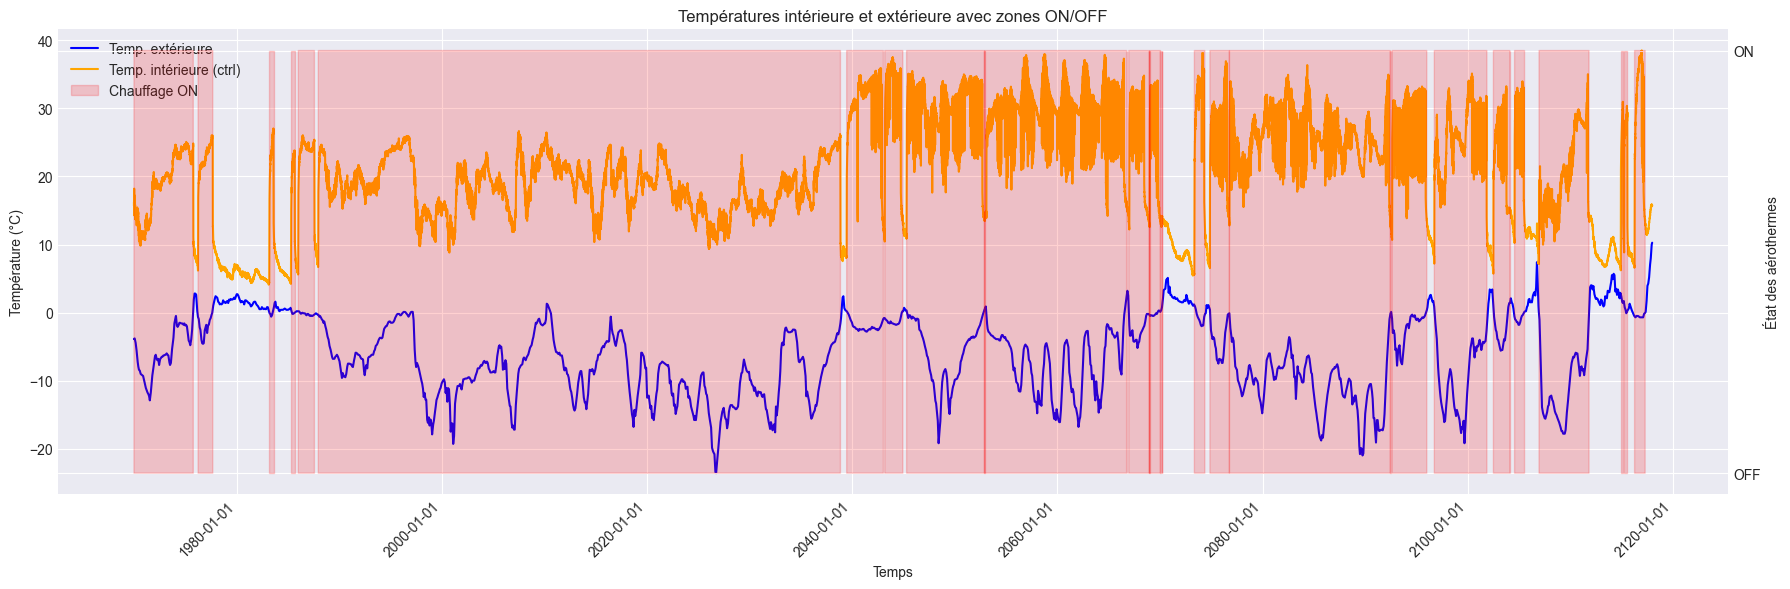

In [230]:
# VISUALISATION TEMPORELLE - Températures + état ON/OFF


fig, ax1 = plt.subplots(figsize=(18, 6))

# Températures
ax1.plot(df.index, df["T_out"], label="Temp. extérieure", color="blue")
ax1.plot(df.index, df["T_ctrl"], label="Temp. intérieure (ctrl)", color="orange")
ax1.set_xlabel("Temps")
ax1.set_ylabel("Température (°C)")
ax1.set_title("Températures intérieure et extérieure avec zones ON/OFF")

# Formatage de l'axe des dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

# État ON/OFF sur axe secondaire
ax2 = ax1.twinx()
ax2.fill_between(df.index, 0, df["OnOff_gmm"], where=df["OnOff_gmm"] == 1,
                 step="post", alpha=0.18, color="red", label="Chauffage ON")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["OFF", "ON"])
ax2.set_ylabel("État des aérothermes")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

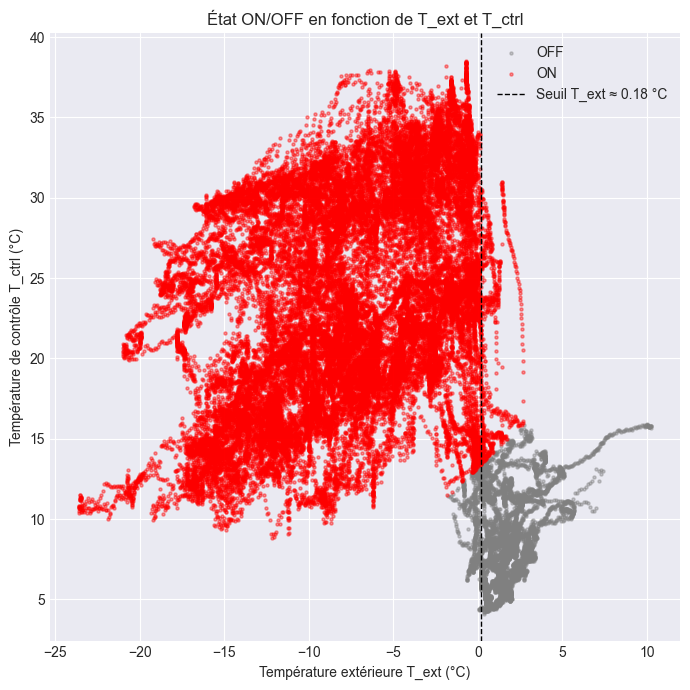

In [231]:
# DIAGRAMME DE DÉCISION - T_out vs T_ctrl coloré par état ON/OFF


fig, ax = plt.subplots(figsize=(7, 7))

mask_on = df["OnOff_gmm"] == 1
ax.scatter(df.loc[~mask_on, "T_out"], df.loc[~mask_on, "T_ctrl"],
           s=5, alpha=0.4, color="gray", label="OFF")
ax.scatter(df.loc[mask_on, "T_out"], df.loc[mask_on, "T_ctrl"],
           s=5, alpha=0.4, color="red", label="ON")

# Seuil principal de l'arbre
ax.axvline(root_thr, color="black", linestyle="--", linewidth=1,
           label=f"Seuil T_ext ≈ {root_thr:.2f} °C")

ax.set_xlabel("Température extérieure T_ext (°C)")
ax.set_ylabel("Température de contrôle T_ctrl (°C)")
ax.set_title("État ON/OFF en fonction de T_ext et T_ctrl")
ax.legend()
plt.tight_layout()
plt.show()

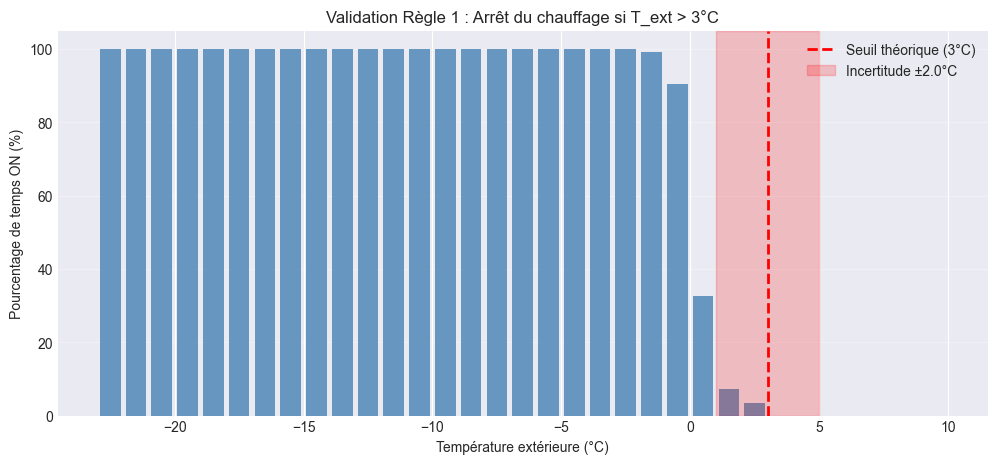

Résumé Règle 1 (avec incertitudes IC 95% Wilson) :
 - Quand T_ext <= 3°C : ON = 87.3% [IC: 87.0% - 87.6%] (n=52947)
 - Quand T_ext > 3°C  : ON = 0.0% [IC: 0.0% - 0.3%] (n=1101)

Note : Incertitude capteur = ±2.0°C (le seuil 3°C réel est entre 1.0°C et 5.0°C)


In [232]:
# VALIDATION SIMPLIFIÉE - Règle 1 : Coupure si T_ext > 3°C

# Incertitude capteur (selon Readme) : ±2°C
INC_CAPTEUR = 2.0

# Fonction pour calculer l'intervalle de confiance binomial (Wilson 95%)
def ic_binomial(p, n, z=1.96):
    """Intervalle de confiance de Wilson pour une proportion."""
    if n == 0:
        return 0, 0
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    marge = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return max(0, centre - marge), min(1, centre + marge)

# On calcule le pourcentage de temps où le chauffage est ON pour chaque degré de température extérieure
bins = np.arange(int(df["T_out"].min()), int(df["T_out"].max()) + 1, 1)
df["T_out_bin"] = pd.cut(df["T_out"], bins=bins)
stats_coupure = df.groupby("T_out_bin", observed=True)["OnOff_gmm"].mean()

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
x_vals = [b.mid for b in stats_coupure.index]
y_vals = stats_coupure.values * 100  # En pourcentage

ax.bar(x_vals, y_vals, width=0.8, color="steelblue", alpha=0.8)
ax.axvline(3, color="red", linestyle="--", linewidth=2, label="Seuil théorique (3°C)")
ax.axvspan(3 - INC_CAPTEUR, 3 + INC_CAPTEUR, alpha=0.2, color="red", label=f"Incertitude ±{INC_CAPTEUR}°C")

ax.set_title("Validation Règle 1 : Arrêt du chauffage si T_ext > 3°C")
ax.set_xlabel("Température extérieure (°C)")
ax.set_ylabel("Pourcentage de temps ON (%)")
ax.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Calcul pour T_ext > 3°C (zone douce)
mask_doux = df["T_out"] > 3
n_doux = mask_doux.sum()
taux_doux = df.loc[mask_doux, "OnOff_gmm"].mean() if n_doux > 0 else 0
ic_doux_lo, ic_doux_hi = ic_binomial(taux_doux, n_doux)

# Calcul pour T_ext <= 3°C (zone froide)
mask_froid = df["T_out"] <= 3
n_froid = mask_froid.sum()
taux_froid = df.loc[mask_froid, "OnOff_gmm"].mean()
ic_froid_lo, ic_froid_hi = ic_binomial(taux_froid, n_froid)

print(f"Résumé Règle 1 (avec incertitudes IC 95% Wilson) :")
print(f" - Quand T_ext <= 3°C : ON = {taux_froid*100:.1f}% [IC: {ic_froid_lo*100:.1f}% - {ic_froid_hi*100:.1f}%] (n={n_froid})")
print(f" - Quand T_ext > 3°C  : ON = {taux_doux*100:.1f}% [IC: {ic_doux_lo*100:.1f}% - {ic_doux_hi*100:.1f}%] (n={n_doux})")
print(f"\nNote : Incertitude capteur = ±{INC_CAPTEUR}°C (le seuil 3°C réel est entre {3-INC_CAPTEUR}°C et {3+INC_CAPTEUR}°C)")

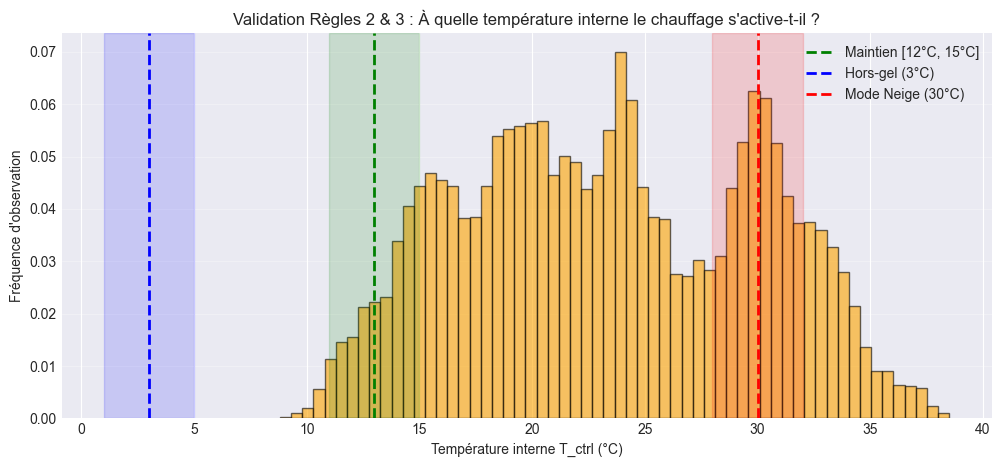

Statistiques quand le chauffage est ON (avec incertitudes) :
 - Moyenne : 23.4 ± 2.0 °C (incertitude combinée : capteur + SEM)
 - Médiane : 23.2 °C
 - Écart-type : 6.4 °C
 - Nombre de points : 46219

Répartition des modes (quand ON) avec IC 95% Wilson :
 - Mode Hors-gel (< 10°C): 0.1% [IC: 0.1% - 0.1%]
 - Mode Neige (> 25°C)   : 39.2% [IC: 38.8% - 39.7%]

Note : Incertitude capteur = ±2.0°C


In [236]:
# VALIDATION SIMPLIFIÉE - Règles 2 & 3 : Consignes (Hors-gel & Neige)

# Incertitude capteur (selon Readme) : ±2°C
INC_CAPTEUR = 2.0

# Fonction IC binomial (Wilson 95%)
def ic_binomial(p, n, z=1.96):
    if n == 0:
        return 0, 0
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    marge = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return max(0, centre - marge), min(1, centre + marge)

# On regarde la distribution de la température interne (T_ctrl) UNIQUEMENT quand le chauffage est ON
df_on = df[df["OnOff_gmm"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_on["T_ctrl"], bins=60, color="orange", alpha=0.6, edgecolor="black", density=True)

# Repères visuels des consignes attendues avec bandes d'incertitude
ax.axvline(13, color="green", linestyle="--", linewidth=2, label="Maintien [12°C, 15°C]")
ax.axvspan(13 - INC_CAPTEUR, 13 + INC_CAPTEUR, alpha=0.15, color="green")
ax.axvline(3, color="blue", linestyle="--", linewidth=2, label="Hors-gel (3°C)")
ax.axvspan(3 - INC_CAPTEUR, 3 + INC_CAPTEUR, alpha=0.15, color="blue")
ax.axvline(30, color="red", linestyle="--", linewidth=2, label="Mode Neige (30°C)")
ax.axvspan(30 - INC_CAPTEUR, 30 + INC_CAPTEUR, alpha=0.15, color="red")

ax.set_title("Validation Règles 2 & 3 : À quelle température interne le chauffage s'active-t-il ?")
ax.set_xlabel("Température interne T_ctrl (°C)")
ax.set_ylabel("Fréquence d'observation")
ax.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Statistiques avec incertitudes
moy_T = df_on['T_ctrl'].mean()
std_T = df_on['T_ctrl'].std()
n_on = len(df_on)
sem_T = std_T / np.sqrt(n_on)  # Erreur standard sur la moyenne

# Incertitude totale sur la moyenne (combinaison capteur + statistique)
inc_totale = np.sqrt(INC_CAPTEUR**2 + sem_T**2)

# Analyse des modes avec intervalles de confiance
part_neige = (df_on['T_ctrl'] > 25).mean()
part_hors_gel = (df_on['T_ctrl'] < 10).mean()
ic_neige = ic_binomial(part_neige, n_on)
ic_gel = ic_binomial(part_hors_gel, n_on)

print("Statistiques quand le chauffage est ON (avec incertitudes) :")
print(f" - Moyenne : {moy_T:.1f} ± {inc_totale:.1f} °C (incertitude combinée : capteur + SEM)")
print(f" - Médiane : {df_on['T_ctrl'].median():.1f} °C")
print(f" - Écart-type : {std_T:.1f} °C")
print(f" - Nombre de points : {n_on}")
print(f"\nRépartition des modes (quand ON) avec IC 95% Wilson :")
print(f" - Mode Hors-gel (< 10°C): {part_hors_gel*100:.1f}% [IC: {ic_gel[0]*100:.1f}% - {ic_gel[1]*100:.1f}%]")
print(f" - Mode Neige (> 25°C)   : {part_neige*100:.1f}% [IC: {ic_neige[0]*100:.1f}% - {ic_neige[1]*100:.1f}%]")
print(f"\nNote : Incertitude capteur = ±{INC_CAPTEUR}°C")

COMPARAISON AVANT / APRÈS LE 26 JANVIER 2024 (avec IC 95%)

Nombre de points : 25555 avant | 28493 après

Taux de chauffage ON (avec IC 95% Wilson) :
 - AVANT 26 janv. : 87.1% [IC: 86.7% - 87.6%]
 - APRÈS 26 janv. : 84.1% [IC: 83.6% - 84.5%]

Avant 26 janv. :
  - T_ext <= 3°C → ON = 87.1% [IC: 86.7% - 87.6%] (n=25555)
  - T_ext > 3°C  → ON = 0.0% [IC: 0.0% - 0.0%] (n=0)

Après 26 janv. :
  - T_ext <= 3°C → ON = 87.4% [IC: 87.0% - 87.8%] (n=27392)
  - T_ext > 3°C  → ON = 0.0% [IC: 0.0% - 0.3%] (n=1101)


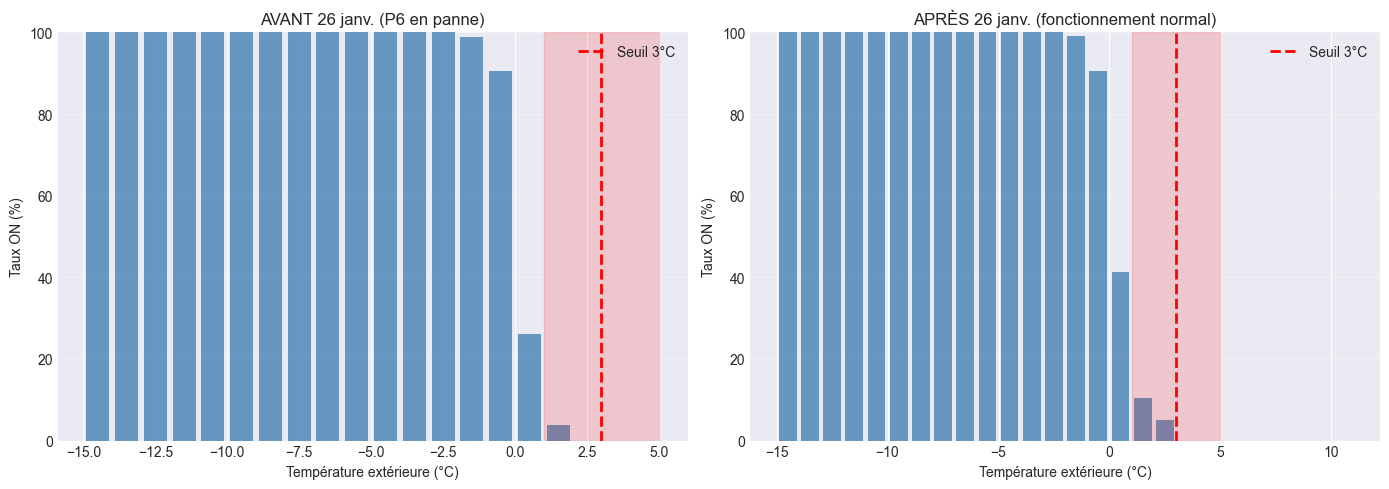


Conclusion (avec incertitudes) :
 - Différence : 3.1 points de pourcentage
  → Les intervalles de confiance ne se chevauchent pas : différence significative


In [ ]:
# ANALYSE COMPARATIVE : Avant vs Après le 26 janvier 2024
# Le 26 janvier 2024, l'aérotherme P6 a été réparé. Avant cette date,
# les autres aérothermes fonctionnaient en continu pour compenser.

# Fonction IC binomial (Wilson 95%)
def ic_binomial_cmp(p, n, z=1.96):
    if n == 0:
        return 0, 0
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    marge = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return max(0, centre - marge), min(1, centre + marge)

date_pivot = pd.Timestamp("2024-01-26")

df_avant = df[df["Time"] < date_pivot].copy()
df_apres = df[df["Time"] >= date_pivot].copy()


print("COMPARAISON AVANT / APRÈS LE 26 JANVIER 2024 (avec IC 95%)")


print(f"\nNombre de points : {len(df_avant)} avant | {len(df_apres)} après")

# Taux ON global avec IC
n_avant, n_apres = len(df_avant), len(df_apres)
taux_avant = df_avant["OnOff_gmm"].mean()
taux_apres = df_apres["OnOff_gmm"].mean()
ic_avant = ic_binomial_cmp(taux_avant, n_avant)
ic_apres = ic_binomial_cmp(taux_apres, n_apres)

print(f"\nTaux de chauffage ON (avec IC 95% Wilson) :")
print(f" - AVANT 26 janv. : {taux_avant*100:.1f}% [IC: {ic_avant[0]*100:.1f}% - {ic_avant[1]*100:.1f}%]")
print(f" - APRÈS 26 janv. : {taux_apres*100:.1f}% [IC: {ic_apres[0]*100:.1f}% - {ic_apres[1]*100:.1f}%]")

# Comportement vs T_ext avec IC
for df_p, label in [(df_avant, "Avant"), (df_apres, "Après")]:
    mask_froid = df_p["T_out"] <= 3
    mask_doux = df_p["T_out"] > 3
    n_froid, n_doux = mask_froid.sum(), mask_doux.sum()
    
    p_froid = df_p.loc[mask_froid, "OnOff_gmm"].mean() if n_froid > 0 else 0
    p_doux = df_p.loc[mask_doux, "OnOff_gmm"].mean() if n_doux > 0 else 0
    ic_froid = ic_binomial_cmp(p_froid, n_froid)
    ic_doux = ic_binomial_cmp(p_doux, n_doux)
    
    print(f"\n{label} 26 janv. :")
    print(f"  - T_ext <= 3°C → ON = {p_froid*100:.1f}% [IC: {ic_froid[0]*100:.1f}% - {ic_froid[1]*100:.1f}%] (n={n_froid})")
    print(f"  - T_ext > 3°C  → ON = {p_doux*100:.1f}% [IC: {ic_doux[0]*100:.1f}% - {ic_doux[1]*100:.1f}%] (n={n_doux})")

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_p, titre in [(axes[0], df_avant, "AVANT 26 janv. (P6 en panne)"),
                         (axes[1], df_apres, "APRÈS 26 janv. (fonctionnement normal)")]:
    bins = np.arange(-15, 15, 1)
    df_p["T_out_bin_cmp"] = pd.cut(df_p["T_out"], bins=bins)
    stats = df_p.groupby("T_out_bin_cmp", observed=True)["OnOff_gmm"].mean()
    x = [b.mid for b in stats.index]
    y = stats.values * 100
    
    ax.bar(x, y, width=0.8, color="steelblue", alpha=0.8)
    ax.axvline(3, color="red", linestyle="--", linewidth=2, label="Seuil 3°C")
    ax.axvspan(1, 5, alpha=0.15, color="red")  # Bande d'incertitude ±2°C
    ax.set_title(titre)
    ax.set_xlabel("Température extérieure (°C)")
    ax.set_ylabel("Taux ON (%)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Test de significativité : les IC se chevauchent-ils?
chevauchement = ic_avant[1] >= ic_apres[0] and ic_apres[1] >= ic_avant[0]

print("\nConclusion (avec incertitudes) :")
print(f" - Différence : {(taux_avant - taux_apres)*100:.1f} points de pourcentage")
if chevauchement:
    print("  → Les intervalles de confiance se chevauchent : pas de différence significative")
else:
    print("  → Les intervalles de confiance ne se chevauchent pas : différence significative")